In [5]:
from dataclasses import dataclass
from typing import List

import numpy as np
import pandas as pd
import yfinance as yf
import sys
import os
import importlib
import matplotlib.pyplot as plt

# Module 4 — Historical Value-at-Risk

This module calculates one-day Historical Value-at-Risk for the hypothetical ETF portfolio.

Historical VaR estimates potential portfolio loss by using the empirical distribution of past portfolio returns. Instead of assuming returns follow a normal distribution, this method directly uses historical return observations.

The key question answered by this module is:

How much could the portfolio lose over one trading day under normal historical market conditions?

This module uses the portfolio return and portfolio value outputs created by the pricing engine.

In [11]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
PROJECT_DIR = "/content/drive/MyDrive/market_risk_project"
SRC_DIR = f"{PROJECT_DIR}/src"
DATA_DIR = f"{PROJECT_DIR}/data"

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print("Project directory:", PROJECT_DIR)
print("Source directory:", SRC_DIR)
print("Data directory:", DATA_DIR)

Project directory: /content/drive/MyDrive/market_risk_project
Source directory: /content/drive/MyDrive/market_risk_project/src
Data directory: /content/drive/MyDrive/market_risk_project/data


In [41]:
importlib.invalidate_caches()

import var_engine # Import the module itself
from var_engine import HistoricalVaREngine

print("HistoricalVaREngine imported successfully.")

#if ever edited var_engine
importlib.reload(var_engine)
from var_engine import HistoricalVaREngine

HistoricalVaREngine imported successfully.


In [37]:
#Historical VaR needs: portfolio_returns.csv and portfolio_value.csv

portfolio_returns = pd.read_csv(
    f"{DATA_DIR}/portfolio_returns.csv",
    index_col=0,
    parse_dates=True
)

portfolio_value = pd.read_csv(
    f"{DATA_DIR}/portfolio_value.csv",
    index_col=0,
    parse_dates=True
)


In [25]:
# Run VaR

historical_var_engine = HistoricalVaREngine(
    portfolio_returns=portfolio_returns,
    portfolio_value=portfolio_value,
    confidence_levels=[0.95, 0.99]
)

var_results = historical_var_engine.run()

In [27]:
var_table = var_results["var_table"]
worst_days = var_results["worst_days"]
tail_95 = var_results["tail_95"]
tail_99 = var_results["tail_99"]
latest_pnl = var_results["latest_pnl"]
current_portfolio_value = var_results["current_portfolio_value"]

print(f"Current Portfolio Value: ${current_portfolio_value:,.2f}")

print("\nHistorical VaR Results:")
display(var_table)


Current Portfolio Value: $194,091.52

Historical VaR Results:


,Confidence Level,Tail Probability,VaR Return Threshold,VaR Amount
0,0.95,0.05,-0.014615,2836.649188
1,0.99,0.01,-0.027085,5256.976986


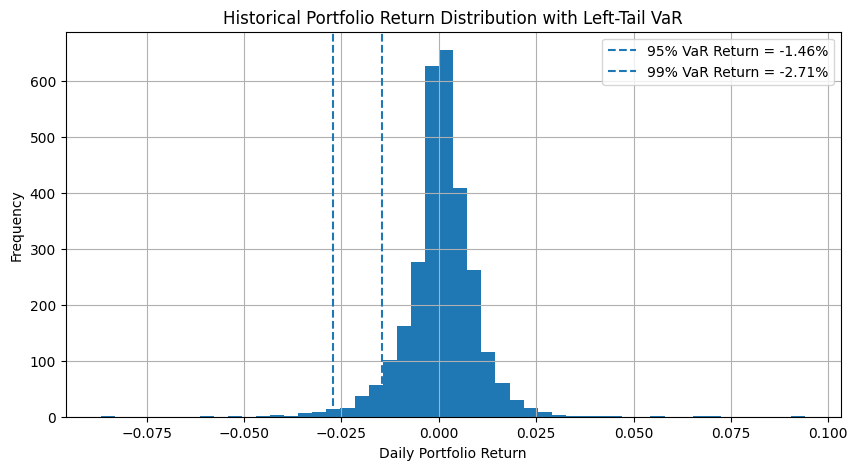

In [29]:

var_95_return = var_table.loc[
    var_table["Confidence Level"] == 0.95,
    "VaR Return Threshold"
].values[0]

var_99_return = var_table.loc[
    var_table["Confidence Level"] == 0.99,
    "VaR Return Threshold"
].values[0]

portfolio_return_series = portfolio_returns.iloc[:, 0]

plt.figure(figsize=(10, 5))
plt.hist(portfolio_return_series, bins=50)

plt.axvline(var_95_return, linestyle="--", label=f"95% VaR Return = {var_95_return:.2%}")
plt.axvline(var_99_return, linestyle="--", label=f"99% VaR Return = {var_99_return:.2%}")

plt.title("Historical Portfolio Return Distribution with VaR")
plt.xlabel("Daily Portfolio Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
recent_returns = portfolio_returns.iloc[:, 0].loc["2024-01-01":]

recent_worst_days = recent_returns.sort_values().head(10)

recent_worst_days_df = pd.DataFrame({
    "Portfolio Return": recent_worst_days,
    "Estimated Loss": -recent_worst_days * current_portfolio_value
})

display(recent_worst_days_df)

,Portfolio Return,Estimated Loss
Date,,
2025-04-04,-0.052065,10105.385928
2025-04-03,-0.042939,8334.183584
2025-04-10,-0.033763,6553.142732
2026-06-05,-0.032798,6365.813696
2024-12-18,-0.029709,5766.228998
2025-03-10,-0.026549,5152.959875
2024-08-05,-0.026134,5072.369418
2025-10-10,-0.023653,4590.782102
2024-07-24,-0.023588,4578.289154


In [30]:
var_table.to_csv(f"{DATA_DIR}/historical_var.csv", index=False)
historical_losses.to_csv(
    f"{DATA_DIR}/historical_losses.csv",
    header=["Historical Loss"]
)
worst_days.to_csv(f"{DATA_DIR}/worst_historical_days.csv")

print("Module 4 outputs saved to Google Drive.")

Module 4 outputs saved to Google Drive.


# Module 6 — Stress Testing

This module applies predefined market shock scenarios to the current hypothetical ETF portfolio.


What if equities fall sharply?
What if technology stocks sell off more severely than the broad market?
What if bonds decline due to an interest rate shock?
What if gold rises during a flight-to-safety event?


In [35]:
weights = pd.read_csv(f"{DATA_DIR}/portfolio_weights.csv")

print("Current Portfolio Positions:")
display(weights)

Current Portfolio Positions:


,Ticker,Quantity,Latest Price,Market Value,Weight
0,SPY,100,746.770020,74677.001953,0.384751
1,QQQ,80,736.400024,58912.001953,0.303527
2,GLD,50,368.380005,18419.000244,0.094899
3,BND,120,73.166000,8779.920044,0.045236
4,VTI,90,370.040009,33303.600769,0.171587


# Step 1 — Define stress scenarios

## Explanation of Stress Scenarios

### 1. Equity Market Crash

| Asset | Shock |
|---|---:|
| SPY | -20% |
| QQQ | -30% |
| VTI | -20% |
| GLD | +10% |
| BND | +3% |

This scenario represents a severe equity market selloff. QQQ receives a larger negative shock because technology and growth stocks are usually more volatile than the broad market. GLD and BND receive positive shocks because investors may move into safer assets during a market crash.

---

### 2. Technology Selloff

| Asset | Shock |
|---|---:|
| QQQ | -25% |
| SPY | -10% |
| VTI | -10% |
| GLD | +5% |
| BND | +2% |

This scenario tests concentration risk in technology-heavy exposure. Since QQQ tracks the Nasdaq 100, it receives the largest negative shock.

---

### 3. Interest Rate Shock

| Asset | Shock |
|---|---:|
| BND | -10% |
| SPY | -5% |
| QQQ | -8% |
| GLD | -3% |
| VTI | -5% |

This scenario represents a sudden rise in interest rates. Bond prices generally fall when interest rates rise, so BND receives a large negative shock. Equities and gold also receive smaller negative shocks because higher rates can reduce asset valuations.

---

### 4. Flight to Safety

| Asset | Shock |
|---|---:|
| SPY | -15% |
| QQQ | -20% |
| VTI | -15% |
| GLD | +15% |
| BND | +6% |

This scenario represents a risk-off market environment. Equities fall, while defensive assets such as gold and bonds rise. This tests whether GLD and BND can partially offset equity losses.

---

### 5. Broad Market Rally

| Asset | Shock |
|---|---:|
| SPY | +10% |
| QQQ | +15% |
| VTI | +10% |
| GLD | -3% |
| BND | -2% |

This is a positive scenario rather than a stress loss scenario. It is included as a comparison case to show how the portfolio performs when risk assets rally.

In [39]:
stress_scenarios = {
    "Equity Market Crash": {
        "SPY": -0.20,
        "QQQ": -0.30,
        "GLD":  0.10,
        "BND":  0.03,
        "VTI": -0.20
    },
    "Technology Selloff": {
        "SPY": -0.10,
        "QQQ": -0.25,
        "GLD":  0.05,
        "BND":  0.02,
        "VTI": -0.10
    },
    "Interest Rate Shock": {
        "SPY": -0.05,
        "QQQ": -0.08,
        "GLD": -0.03,
        "BND": -0.10,
        "VTI": -0.05
    },
    "Flight to Safety": {
        "SPY": -0.15,
        "QQQ": -0.20,
        "GLD":  0.15,
        "BND":  0.06,
        "VTI": -0.15
    },
    "Broad Market Rally": {
        "SPY":  0.10,
        "QQQ":  0.15,
        "GLD": -0.03,
        "BND": -0.02,
        "VTI":  0.10
    }
}

In [46]:
scenario_name = "Equity Market Crash"
shocks = stress_scenarios[scenario_name]

positions = pd.read_csv(f"{DATA_DIR}/portfolio_weights.csv")
scenario_df = positions.copy()

scenario_df["Shock"] = scenario_df["Ticker"].map(shocks)
scenario_df["Shock"] = scenario_df["Shock"].fillna(0)

scenario_df["Stress PnL"] = scenario_df["Market Value"] * scenario_df["Shock"]
scenario_df["Stressed Market Value"] = scenario_df["Market Value"] + scenario_df["Stress PnL"]

display(scenario_df)

,Ticker,Quantity,Latest Price,Market Value,Weight,Shock,Stress PnL,Stressed Market Value
0,SPY,100,746.770020,74677.001953,0.384751,-0.20,-14935.400391,59741.601562
1,QQQ,80,736.400024,58912.001953,0.303527,-0.30,-17673.600586,41238.401367
2,GLD,50,368.380005,18419.000244,0.094899,0.10,1841.900024,20260.900269
3,BND,120,73.166000,8779.920044,0.045236,0.03,263.397601,9043.317645
4,VTI,90,370.040009,33303.600769,0.171587,-0.20,-6660.720154,26642.880615


## Step 2 — Aggregate Stress Test Results

Iterate through each predefined stress scenario, calculate the total PnL and new portfolio value under stress, and store the results in a summary table.

In [47]:
scenario_summary = []

for scenario_name, shocks in stress_scenarios.items():
    scenario_df = weights.copy()
    scenario_df["Shock"] = scenario_df["Ticker"].map(shocks)
    scenario_df["Shock"] = scenario_df["Shock"].fillna(0)
    scenario_df["Stress PnL"] = scenario_df["Market Value"] * scenario_df["Shock"]
    scenario_df["Stressed Market Value"] = scenario_df["Market Value"] + scenario_df["Stress PnL"]

    total_stress_pnl = scenario_df["Stress PnL"].sum()
    total_stressed_value = scenario_df["Stressed Market Value"].sum()
    initial_portfolio_value = scenario_df["Market Value"].sum()

    scenario_summary.append({
        "Scenario": scenario_name,
        "Initial Portfolio Value": initial_portfolio_value,
        "Total Stress PnL": total_stress_pnl,
        "Stressed Portfolio Value": total_stressed_value,
        "Percentage Loss": total_stress_pnl / initial_portfolio_value
    })

scenario_summary_df = pd.DataFrame(scenario_summary)

print("\nStress Scenario Summary:")
display(scenario_summary_df.style.format({
    "Initial Portfolio Value": "${:,.2f}",
    "Total Stress PnL": "${:,.2f}",
    "Stressed Portfolio Value": "${:,.2f}",
    "Percentage Loss": "{:,.2%}"
}))


Stress Scenario Summary:


,Scenario,Initial Portfolio Value,Total Stress PnL,Stressed Portfolio Value,Percentage Loss
0,Equity Market Crash,"$194,091.52","$-37,164.42","$156,927.10",-19.15%
1,Technology Selloff,"$194,091.52","$-24,429.51","$169,662.01",-12.59%
2,Interest Rate Shock,"$194,091.52","$-11,542.55","$182,548.97",-5.95%
3,Flight to Safety,"$194,091.52","$-24,689.85","$169,401.68",-12.72%
4,Broad Market Rally,"$194,091.52","$18,906.69","$212,998.22",9.74%
